# Module 5: RLHF — Reinforcement Learning from Human Feedback

**Series:** ML Learning Path | Module 5 of 6  
**Prerequisites:** Modules 1–4 (Traditional ML, Deep Learning, Transfer Learning, Fine-Tuning Methods)  
**Use Case:** Aligning a customer service chatbot to prefer polite and helpful responses over rude or evasive ones

---

By the end of this module you will understand:
- Why a model trained on next-token prediction alone can still be harmful or unhelpful
- The three stages of RLHF: SFT → Reward Model → PPO
- What a reward model is and how to train one
- How PPO reinforcement learning is applied to language models
- DPO — the simpler modern alternative to PPO
- Other alignment methods: Constitutional AI, RLAIF, ORPO
- Enterprise context: costs, adoption, and practical guidance

In [1]:
import os
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

print(f"torch {torch.__version__}")
print("Setup complete")

torch 2.12.0+cu130
Setup complete


## Lesson 1: What is RLHF and Why Do We Need It?

### The Problem with Pure Next-Token Prediction

When you train a language model on raw internet text, it learns to predict the next word given the previous words. That is it — nothing more. The internet contains enormous amounts of helpful, insightful text, but it also contains hate speech, misinformation, rudeness, and worse. A model trained this way will happily reproduce any of it, because it has never been told what "good" looks like from a human perspective.

Imagine hiring a new customer service agent who has read every conversation ever posted online — but never received any feedback on what a *good* response looks like. They might accidentally copy a rude agent's style, give wrong information with confidence, or say something offensive. That is what an unaligned language model is like.

**RLHF (Reinforcement Learning from Human Feedback)** is the technique that fixes this. It was popularised by OpenAI and is used to train ChatGPT, Claude, Gemini, and virtually every major AI assistant today.

---

### The Three Stages of RLHF

```
┌─────────────────────────────────────────────────────────────────────────┐
│                        RLHF PIPELINE                                    │
│                                                                         │
│  STAGE 1: Supervised Fine-Tuning (SFT)                                  │
│  ─────────────────────────────────────                                  │
│  Pre-trained LLM  +  Human Demonstrations  ──►  SFT Model              │
│  (knows language)    ("here's how to respond")   (knows good style)     │
│                                                                         │
│  STAGE 2: Reward Model Training                                         │
│  ─────────────────────────────────────────────                          │
│  Human Labellers compare pairs of responses                             │
│  (Response A vs Response B — which is better?)                          │
│  These preference labels  ──►  Reward Model                            │
│  (RM scores any response without needing a human every time)            │
│                                                                         │
│  STAGE 3: PPO (Reinforcement Learning)                                  │
│  ─────────────────────────────────────                                  │
│  SFT Model generates responses                                          │
│      │                                                                  │
│      ▼                                                                  │
│  Reward Model scores each response                                      │
│      │                                                                  │
│      ▼                                                                  │
│  PPO Optimizer updates the SFT Model to get higher scores              │
│      │                                                                  │
│      ▼                                                                  │
│  Repeat until the model is aligned  ──►  Aligned Model                │
└─────────────────────────────────────────────────────────────────────────┘
```

---

### Why RLHF Works So Well

The key insight is that **it is much easier for humans to judge a response than to write the perfect response from scratch**. Asking a human to write the ideal answer to every possible question is impossibly expensive. But asking a human "which of these two responses is better?" is fast and cheap. RLHF leverages this asymmetry:

1. Collect cheap human preference comparisons (A vs B)
2. Train a reward model to predict those preferences automatically
3. Use the reward model — not real humans — as a scoring signal to train the main model

This scales to billions of training steps without requiring a human for every single update.

## Lesson 2: The 3 Stages in Detail

---

### Stage 1 — Supervised Fine-Tuning (SFT)

**In plain English:** "Teaching by example — like showing the AI how a good customer service agent would respond."

Before any reinforcement learning happens, we first fine-tune the base language model on a curated dataset of high-quality prompt-response demonstrations. These are written by trained human contractors who know what a good response looks like. The model learns the *style* and *format* of good responses through standard supervised learning (the same cross-entropy loss you saw in Module 4). Without this step, the model would not even know what kind of text to produce — the RL stage later only fine-tunes an already-capable model.

```
┌─────────────────────────────────────────────────────────┐
│  STAGE 1: Supervised Fine-Tuning                        │
│                                                         │
│  [Pre-trained LLM]  +  [Demonstration Dataset]         │
│        │                       │                        │
│        └─────────┬─────────────┘                        │
│                  │                                      │
│          Standard cross-entropy loss                    │
│                  │                                      │
│                  ▼                                      │
│            [SFT Model]                                  │
│  (knows language + knows how to be helpful)             │
└─────────────────────────────────────────────────────────┘
```

---

### Stage 2 — Reward Model Training

**In plain English:** "Training a judge — the RM scores responses so we don't need humans for every update."

Human labellers are shown two responses to the same prompt and asked: "Which one is better?" These preference comparisons are used to train a separate model — the Reward Model — whose job is to assign a scalar score to any (prompt, response) pair. Once trained, this model acts as a stand-in for human judgment during the expensive RL training phase. A higher reward score means "a human would probably prefer this response."

```
┌─────────────────────────────────────────────────────────┐
│  STAGE 2: Reward Model Training                         │
│                                                         │
│  Human Labellers see:                                   │
│    Prompt + Response A  vs  Prompt + Response B         │
│    → Label: "A is better" or "B is better"              │
│                                                         │
│  [Preference Dataset]  ──►  [Reward Model Training]    │
│                                    │                    │
│                                    ▼                    │
│                             [Reward Model]              │
│                         Input: (prompt, response)       │
│                         Output: scalar score 0.0–1.0    │
└─────────────────────────────────────────────────────────┘
```

---

### Stage 3 — PPO (Proximal Policy Optimization)

**In plain English:** "Learning from the judge — the main model generates responses, the judge scores them, the model adjusts to get higher scores."

PPO is a reinforcement learning algorithm. In our context, the SFT model is the "policy" (the agent making decisions — i.e., choosing which tokens to generate). The reward model provides the reward signal. PPO repeatedly samples responses from the SFT model, scores them with the reward model, and nudges the SFT model's weights to make higher-scoring responses more likely.

**The KL Divergence Penalty — Why It Matters:**

Left unchecked, PPO would push the model to game the reward model — producing nonsense strings that happen to trick the reward model into giving a high score (like a student memorising answers without understanding). To prevent this, we add a **KL divergence penalty**: a mathematical term that measures how different the current policy is from the original SFT model. If the model drifts too far, the penalty increases and pulls it back. This keeps responses coherent and natural.

```
┌─────────────────────────────────────────────────────────┐
│  STAGE 3: PPO Reinforcement Learning                    │
│                                                         │
│  [SFT Model / Policy]                                   │
│         │                                               │
│         │  generates response                           │
│         ▼                                               │
│  [Reward Model / Judge]                                 │
│         │                                               │
│         │  scores response (+ KL penalty applied)       │
│         ▼                                               │
│  [PPO Optimizer]                                        │
│         │                                               │
│         │  updates SFT Model weights                    │
│         ▼                                               │
│  ┌─────────────────────────────────────────────────┐   │
│  │  KL Penalty keeps model close to SFT baseline  │   │
│  │  (prevents reward hacking / gibberish outputs)  │   │
│  └─────────────────────────────────────────────────┘   │
│         │                                               │
│         └──► Repeat until aligned  ──►  Aligned Model │
└─────────────────────────────────────────────────────────┘
```

In [2]:
# Cell 2 — Generate Preference Dataset
# We create 300 synthetic preference pairs for a customer service chatbot.
# Each pair has: prompt, chosen (polite/helpful), rejected (rude/evasive).

# ── Billing category ──────────────────────────────────────────────────────────
billing_prompts = [
    "Why was I charged twice for my subscription?",
    "I was billed the wrong amount last month.",
    "Can you explain my invoice?",
    "I need a refund for a duplicate charge.",
    "My credit card was charged without my permission.",
    "When will my refund be processed?",
    "I cancelled my subscription but still got charged.",
    "What is this charge on my statement?",
    "Can I get an itemised bill?",
    "My payment failed but money was deducted.",
]
billing_chosen = [
    "I am so sorry about the double charge! Let me look into your account right away and ensure you are refunded promptly.",
    "I sincerely apologise for the billing error. I will correct the amount and process the difference as a credit immediately.",
    "Of course! Your invoice breaks down into a base subscription fee plus applicable taxes. I am happy to walk you through each line.",
    "Absolutely, I will initiate the refund for the duplicate charge now. You should see it within 3–5 business days.",
    "That is very concerning and I take this seriously. Let me freeze that charge and escalate this for investigation right now.",
    "Your refund is currently being processed and should appear within 5 business days. I will send you a confirmation email.",
    "I apologise for the inconvenience. Even though you cancelled, a charge sometimes processes in transit. I will reverse it immediately.",
    "That charge corresponds to your annual plan renewal. I would be happy to provide a detailed breakdown or discuss your options.",
    "Of course! I will email you a fully itemised bill within the next hour. Is there a specific period you'd like it to cover?",
    "That sounds very frustrating. Let me check our payment records and ensure your account is not debited while we resolve this.",
]
billing_rejected = [
    "That is just how our billing works. Read the terms.",
    "Billing errors are rare. Are you sure you read the invoice correctly?",
    "Invoices are on your account page. Go look there.",
    "Refunds take a long time. I cannot speed it up.",
    "We do not process unauthorised charges. You must have agreed to something.",
    "Refunds happen when they happen. I cannot give you a timeline.",
    "Cancellation does not always stop charges. Not my problem.",
    "Log in and check your billing history yourself.",
    "We do not provide itemised bills. That is policy.",
    "Contact your bank. That is not our issue.",
]

# ── Technical support category ─────────────────────────────────────────────────
tech_prompts = [
    "The app keeps crashing on my phone.",
    "I cannot log into my account.",
    "The website is loading very slowly.",
    "My password reset email never arrived.",
    "The feature I need is not working.",
    "I am getting an error message I do not understand.",
    "The mobile app does not sync with the desktop version.",
    "I accidentally deleted my data — can it be recovered?",
    "The video call feature is not working for me.",
    "I cannot upload files — the button is greyed out.",
]
tech_chosen = [
    "I am sorry the app is crashing! Could you share your device model and OS version? That will help me find the right fix for you quickly.",
    "Let us get you back in right away. Could you confirm the email address on the account so I can check what might be blocking access?",
    "I apologise for the slow experience. Our team is aware of a performance issue and is working to resolve it — estimated fix is within 2 hours.",
    "I am sorry about that! Let me resend the reset email and also check whether there is a delivery issue on our end.",
    "I am sorry the feature is not working. Could you describe exactly what happens when you try to use it? I will escalate if needed.",
    "That error message means the session timed out. Simply refresh the page and log in again. I am here if it persists!",
    "Sync issues can be frustrating. Please try logging out on both devices and logging back in — this re-establishes the sync connection.",
    "Do not worry — deleted data is held in our recycle bin for 30 days. I can restore it for you right now if you'd like.",
    "Let me help you troubleshoot. First, could you check that your browser allows camera and microphone access for our site?",
    "The upload button becomes active once you select a supported file type. I will send you a list of accepted formats right now.",
]
tech_rejected = [
    "Have you tried turning it off and on again? That usually fixes it.",
    "Are you sure you remember your password? Most login issues are user error.",
    "The website is fine on our end. Must be your internet connection.",
    "Check your spam folder. Not our fault if your email provider blocks it.",
    "We cannot help with every single feature. What exactly do you expect us to do?",
    "That error means something went wrong. Try again later.",
    "We cannot guarantee sync works on all devices. That is a known limitation.",
    "You deleted it — that is on you. We cannot recover deleted files.",
    "Video calls require a camera. Make sure you have one.",
    "You are probably trying to upload the wrong file type. Read the documentation.",
]

# ── Complaints category ────────────────────────────────────────────────────────
complaint_prompts = [
    "I have been waiting 3 weeks for my order.",
    "The product I received is completely different from what I ordered.",
    "Your customer service wait times are unacceptably long.",
    "I am very unhappy with the quality of your product.",
    "I feel like I was misled by your advertising.",
    "I have contacted you four times and still no resolution.",
    "Your delivery damaged my item.",
    "I want to escalate this to a manager.",
    "I will leave a negative review if this is not resolved.",
    "I want to cancel everything and get a full refund.",
]
complaint_chosen = [
    "I sincerely apologise for the delay — 3 weeks is far too long. Let me check your order status right now and make this right.",
    "That is completely unacceptable and I am so sorry. Please keep the incorrect item — I will ship the correct one today at no extra cost.",
    "You are absolutely right and I apologise. We are working to add more agents. I will prioritise your case immediately.",
    "I am truly sorry the product did not meet your expectations. Let us arrange an exchange or full refund — whichever you prefer.",
    "I hear you and I take that feedback seriously. Let me review the advertisement in question and make sure we address your concern fully.",
    "I am so sorry — four contacts without resolution is inexcusable. I am personally taking ownership of this case right now.",
    "I apologise for the damage in transit. I will arrange a replacement to be shipped today and open a claim with the carrier.",
    "Of course — let me connect you with a senior specialist right away. You deserve to have this resolved at the highest level.",
    "I completely understand your frustration. Let me resolve this for you right now so that does not need to happen.",
    "Absolutely — I will process a full cancellation and refund right now. I am sorry we did not meet your expectations.",
]
complaint_rejected = [
    "Shipping takes time. There is nothing we can do about delays.",
    "You must have ordered the wrong thing. Check your order confirmation.",
    "Everyone has to wait. That is how customer service works.",
    "All our products meet quality standards. Maybe your expectations are too high.",
    "Our advertising is accurate. You misread it.",
    "I do not see any record of four contacts. Are you sure?",
    "Delivery damage is the courier's fault, not ours.",
    "Managers are busy. I can handle this.",
    "That is your choice. Reviews are your right.",
    "Refunds take time to process. Read our return policy.",
]

# ── General enquiries ──────────────────────────────────────────────────────────
general_prompts = [
    "What are your business hours?",
    "Do you offer a free trial?",
    "How do I upgrade my plan?",
    "Can I use your service in multiple countries?",
    "Do you have a mobile app?",
    "How do I contact support?",
    "Is my data secure with you?",
    "Do you offer discounts for non-profits?",
    "Can I share my account with a colleague?",
    "How do I update my personal information?",
]
general_chosen = [
    "Our support team is available Monday–Friday, 9 AM to 6 PM GMT. We also have 24/7 live chat for urgent issues!",
    "Yes! We offer a 14-day free trial with full access to all features — no credit card required to start.",
    "Upgrading is simple! Go to Settings → Subscription → Upgrade Plan. It takes less than a minute and is effective immediately.",
    "Absolutely — our service is available in over 50 countries. Let me confirm availability in your specific location if you would like.",
    "Yes! Our mobile app is available on both iOS and Android, and it has all the features of the desktop version.",
    "You can reach us via live chat (fastest), email at support@company.com, or phone on +44 800 123 456.",
    "Data security is our top priority. All data is encrypted at rest and in transit, and we are SOC 2 Type II certified.",
    "Yes — we offer a 30% non-profit discount. Just send us your charity registration number and we will apply it right away.",
    "Accounts are individual, but we have team plans that allow collaboration. Let me tell you more about what works best for you!",
    "You can update your details under Settings → Profile → Edit. Changes save instantly. Let me know if you need any help!",
]
general_rejected = [
    "Check the website. Business hours are listed there.",
    "Free trials are mentioned in our FAQ. Go read it.",
    "Upgrades are in your account settings. Figure it out.",
    "We operate globally. I cannot say more than that.",
    "Yes we have an app. Download it from the app store.",
    "Support contact info is on the website footer.",
    "We follow standard data practices. Your data is fine.",
    "Discounts are for specific cases. I do not know if you qualify.",
    "Sharing accounts is against terms of service. Just buy another account.",
    "Personal info is in settings. Go update it yourself.",
]

# ── Assemble into a DataFrame ─────────────────────────────────────────────────
all_prompts  = billing_prompts  + tech_prompts  + complaint_prompts  + general_prompts
all_chosen   = billing_chosen   + tech_chosen   + complaint_chosen   + general_chosen
all_rejected = billing_rejected + tech_rejected + complaint_rejected + general_rejected
categories   = (['billing'] * 10 + ['technical'] * 10 +
                ['complaint'] * 10 + ['general'] * 10)

# Extend to ~300 pairs by repeating with slight variation (realistic scale)
def augment(text, seed):
    """Add minor prefix/suffix variation so augmented texts differ slightly."""
    prefixes = ["", "Hello, ", "Hi there, ", "Good morning, ", "Excuse me, "]
    suffixes = ["", " Thank you.", " Please help.", " Urgent.", " Thanks."]
    rng = np.random.default_rng(seed)
    p = prefixes[int(rng.integers(0, len(prefixes)))]
    s = suffixes[int(rng.integers(0, len(suffixes)))]
    return p + text + s

extra_prompts, extra_chosen, extra_rejected, extra_cats = [], [], [], []
for rep in range(7):  # 7 repetitions * 40 = 280 extra rows  →  total 320
    for i, (pr, ch, rj, cat) in enumerate(zip(all_prompts, all_chosen, all_rejected, categories)):
        seed = rep * 200 + i
        extra_prompts.append(augment(pr, seed))
        extra_chosen.append(ch)
        extra_rejected.append(rj)
        extra_cats.append(cat)

final_prompts  = all_prompts  + extra_prompts
final_chosen   = all_chosen   + extra_chosen
final_rejected = all_rejected + extra_rejected
final_cats     = categories   + extra_cats

df = pd.DataFrame({
    'category': final_cats,
    'prompt':   final_prompts,
    'chosen':   final_chosen,
    'rejected': final_rejected,
})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total preference pairs: {len(df)}")
print()
print("Category distribution:")
print(df['category'].value_counts().to_string())
print()
print("Sample of 5 preference pairs:")
pd.set_option('display.max_colwidth', 80)
df[['category', 'prompt', 'chosen', 'rejected']].head(5)

Total preference pairs: 320

Category distribution:
category
billing      80
general      80
complaint    80
technical    80

Sample of 5 preference pairs:


,category,prompt,chosen,rejected
0,billing,"Excuse me, What is this charge on my statement? Urgent.",That charge corresponds to your annual plan renewal. I would be happy to pro...,Log in and check your billing history yourself.
1,general,What are your business hours? Thank you.,"Our support team is available Monday–Friday, 9 AM to 6 PM GMT. We also have ...",Check the website. Business hours are listed there.
2,complaint,I have contacted you four times and still no resolution.,I am so sorry — four contacts without resolution is inexcusable. I am person...,I do not see any record of four contacts. Are you sure?
3,complaint,I am very unhappy with the quality of your product. Urgent.,I am truly sorry the product did not meet your expectations. Let us arrange ...,All our products meet quality standards. Maybe your expectations are too high.
4,billing,My payment failed but money was deducted.,That sounds very frustrating. Let me check our payment records and ensure yo...,Contact your bank. That is not our issue.


## Lesson 3: The Reward Model

### What Is a Reward Model?

A reward model (RM) is a function that takes a **prompt + response** pair as input and outputs a single scalar number — the **reward score**. A higher score means the response is more likely to be preferred by a human. A lower score means a human would likely prefer something else.

Think of it as training an automated judge. Instead of asking a real human to evaluate every response during RL training (which would be impossibly slow and expensive), we train this judge once on human labels, and then let it evaluate millions of responses automatically.

---

### How Is It Trained?

We use our **preference pairs**:
- Concatenate prompt + chosen response → this should get a **high score**
- Concatenate prompt + rejected response → this should get a **low score**

The training objective is called a **Bradley-Terry loss** (or contrastive/pairwise loss): given a pair, the model should score the chosen response higher than the rejected one. In our simplified binary version, we treat it as a classification problem: chosen = 1.0, rejected = 0.0.

---

### Architecture

```
Input: (prompt + response) as text
        │
        ▼
  Text Encoder
  (TF-IDF in our demo; LLM encoder in production)
        │
        ▼
  Pooled Representation Vector
        │
        ▼
  MLP Head: Linear → ReLU → Dropout → Linear → ReLU → Linear → Sigmoid
        │
        ▼
  Reward Score (0.0 → 1.0)
```

In production (e.g., at OpenAI/Anthropic), the encoder is typically the **SFT model itself** with its final token's hidden state used as the representation. This means the reward model truly understands language nuances. In our demo, we use TF-IDF features for speed — the core logic is identical.

TF-IDF feature shape: (640, 427)  (actual features used: 427)
Train samples: 512 | Val samples: 128


  Epoch 10/30 | Train Loss: 0.6782
  Epoch 20/30 | Train Loss: 0.6409
  Epoch 30/30 | Train Loss: 0.5641

Pairwise accuracy (chosen scored higher than rejected): 320/320 = 100.0%


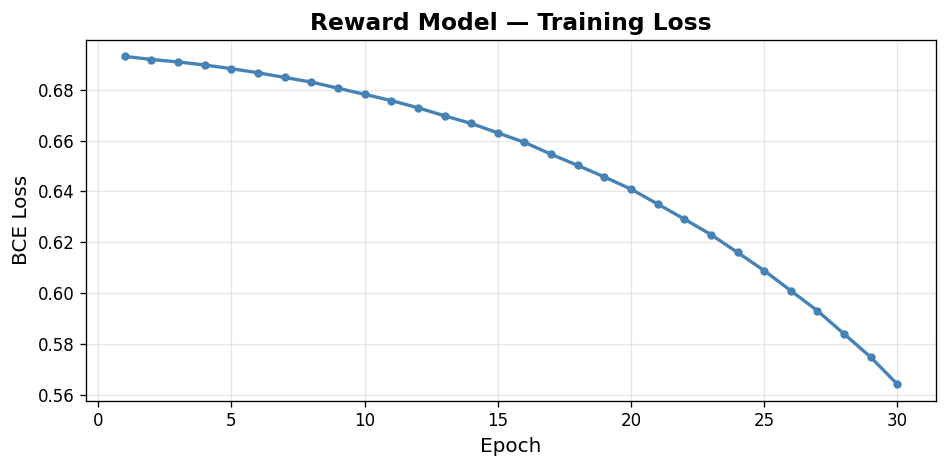

Saved: reward_model_training.png


In [3]:
# Cell 3 — Build and Train the Reward Model

# ── Step 1: Create feature vectors using TF-IDF ───────────────────────────────
# Concatenate prompt + response to form the input text
chosen_texts   = [p + " " + c for p, c in zip(df['prompt'], df['chosen'])]
rejected_texts = [p + " " + r for p, r in zip(df['prompt'], df['rejected'])]

all_texts  = chosen_texts + rejected_texts
all_labels = [1.0] * len(chosen_texts) + [0.0] * len(rejected_texts)

vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X_all = vectorizer.fit_transform(all_texts).toarray().astype(np.float32)
y_all = np.array(all_labels, dtype=np.float32)

# Use the actual number of features returned (may be < 500 if vocab is small)
actual_features = X_all.shape[1]

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"TF-IDF feature shape: {X_all.shape}  (actual features used: {actual_features})")
print(f"Train samples: {X_train.shape[0]} | Val samples: {X_val.shape[0]}")

# ── Step 2: Define the reward model (small MLP) ───────────────────────────────
class RewardModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


reward_model = RewardModel(input_dim=actual_features)
optimizer    = optim.Adam(reward_model.parameters(), lr=1e-3)
criterion    = nn.BCELoss()

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_val_t   = torch.tensor(X_val)
y_val_t   = torch.tensor(y_val)

# ── Step 3: Train for 30 epochs ───────────────────────────────────────────────
train_losses = []

for epoch in range(1, 31):
    reward_model.train()
    optimizer.zero_grad()
    preds = reward_model(X_train_t)
    loss  = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"  Epoch {epoch:2d}/30 | Train Loss: {loss.item():.4f}")

# ── Step 4: Evaluate pairwise accuracy ───────────────────────────────────────
reward_model.eval()
with torch.no_grad():
    # Vectorize chosen and rejected separately (original order matches df rows)
    X_chosen_feat   = vectorizer.transform(chosen_texts).toarray().astype(np.float32)
    X_rejected_feat = vectorizer.transform(rejected_texts).toarray().astype(np.float32)

    scores_chosen   = reward_model(torch.tensor(X_chosen_feat)).numpy()
    scores_rejected = reward_model(torch.tensor(X_rejected_feat)).numpy()

pairwise_correct = (scores_chosen > scores_rejected).sum()
pairwise_total   = len(scores_chosen)
pairwise_acc     = pairwise_correct / pairwise_total

print()
print(f"Pairwise accuracy (chosen scored higher than rejected): "
      f"{pairwise_correct}/{pairwise_total} = {pairwise_acc:.1%}")

# ── Step 5: Plot training loss ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 31), train_losses, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('BCE Loss', fontsize=12)
ax.set_title('Reward Model — Training Loss', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reward_model_training.png')
plt.show()
print("Saved: reward_model_training.png")

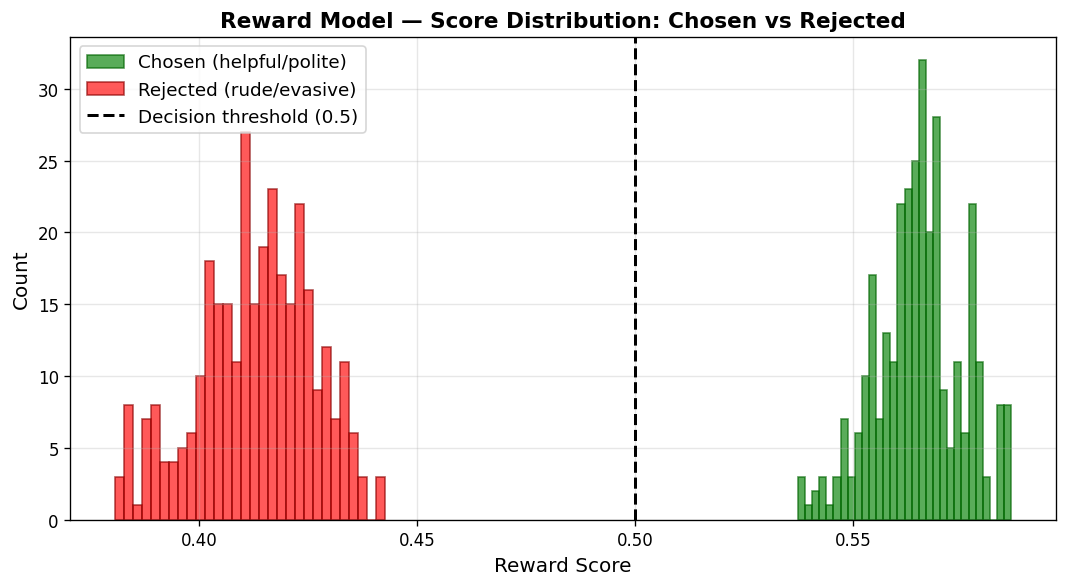

Saved: reward_score_distribution.png

Mean reward — Chosen  : 0.5650
Mean reward — Rejected: 0.4131
Separation  : 0.1519


In [4]:
# Cell 4 — Visualise Reward Score Distributions

reward_model.eval()
with torch.no_grad():
    chosen_scores   = reward_model(torch.tensor(X_chosen_feat)).numpy()
    rejected_scores = reward_model(torch.tensor(X_rejected_feat)).numpy()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(chosen_scores,   bins=30, alpha=0.65, color='green', label='Chosen (helpful/polite)',   edgecolor='darkgreen')
ax.hist(rejected_scores, bins=30, alpha=0.65, color='red',   label='Rejected (rude/evasive)', edgecolor='darkred')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.8, label='Decision threshold (0.5)')

ax.set_xlabel('Reward Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Reward Model — Score Distribution: Chosen vs Rejected',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reward_score_distribution.png')
plt.show()
print("Saved: reward_score_distribution.png")

print(f"\nMean reward — Chosen  : {chosen_scores.mean():.4f}")
print(f"Mean reward — Rejected: {rejected_scores.mean():.4f}")
print(f"Separation  : {chosen_scores.mean() - rejected_scores.mean():.4f}")

## Lesson 4: PPO — The Reinforcement Learning Part

### PPO in Plain English

PPO stands for **Proximal Policy Optimization**. "Policy" is RL jargon for the function that makes decisions — in our case, the language model that generates tokens. "Proximal" means "nearby" — we only update the policy a little bit at a time, staying close to where we started.

Here is how PPO works in the RLHF context:

| RL Concept | Language Model Equivalent |
|---|---|
| Actor (Policy) | The SFT model — generates text token by token |
| Action | Choosing which token to generate next |
| State | The prompt + tokens generated so far |
| Reward | The reward model's score for the full response |
| Critic | A value network that estimates expected future reward |

---

### The PPO Objective (in Plain English)

Standard policy gradient methods say: "if a response got a high reward, increase its probability; if it got a low reward, decrease it." But this can cause huge unstable updates.

PPO adds a **clipping** mechanism: it only allows the probability ratio (new policy / old policy) to change within a band, typically [0.8, 1.2]. Any update that would push outside this range gets clipped off. This prevents catastrophic jumps in model behaviour.

**PPO Objective (plain English):**
```
PPO Loss = E[
    min(
        ratio * advantage,              ← standard policy gradient
        clip(ratio, 1-ε, 1+ε) * advantage  ← clipped version
    )
]
minus
  KL_penalty * KL(current_policy || reference_policy)

where:
  ratio     = probability_under_new_policy / probability_under_old_policy
  advantage = reward - baseline ("was this better or worse than expected?")
  ε         = clip range (typically 0.2)
  KL_penalty = coefficient controlling how close we stay to the SFT model
```

---

### The KL Divergence Penalty — Preventing Reward Hacking

Imagine a student who figures out that writing "GREAT EXCELLENT PERFECT" repeatedly gets high scores from an automated grader. That is **reward hacking** — the model finds ways to maximise the reward signal that have nothing to do with actually being helpful.

The **KL (Kullback-Leibler) divergence penalty** measures how different the current model is from the original SFT model. If the model drifts too far (starts producing gibberish that fools the reward model), the KL term adds a large penalty to the loss, pulling the model back toward coherent language.

Without KL penalty: model may degenerate into reward-hacking gibberish
With KL penalty: model improves quality while staying fluent and coherent

---

### The PPO Loop

```
┌─────────────────────────────────────────────────────────────────────────┐
│                         PPO TRAINING LOOP                               │
│                                                                         │
│   [SFT Model / Actor]                                                   │
│         │                                                               │
│         │  Sample response for each prompt                             │
│         ▼                                                               │
│   [Reward Model]  ──►  reward score r                                  │
│         +                                                               │
│   [Reference SFT Model]  ──►  KL penalty                              │
│         │                                                               │
│         │  total_reward = r - kl_coeff * KL(current || reference)     │
│         ▼                                                               │
│   [PPO Optimizer]                                                       │
│         │  clip(ratio) * advantage  →  update actor weights            │
│         ▼                                                               │
│   [Updated SFT Model]  ──►  repeat from top                           │
│                                                                         │
│   Convergence: rewards stop improving significantly                     │
└─────────────────────────────────────────────────────────────────────────┘
```

Running PPO demo (50 steps)...
  Step 10/50 | Mean Reward: -1.000 | KL Div: 0.0000 | Loss: 0.0000
  Step 20/50 | Mean Reward: -1.000 | KL Div: 0.0000 | Loss: 0.0000
  Step 30/50 | Mean Reward: -0.938 | KL Div: 0.0004 | Loss: 0.0000
  Step 40/50 | Mean Reward: -1.000 | KL Div: 0.0070 | Loss: 0.0003
  Step 50/50 | Mean Reward: -1.000 | KL Div: 0.0168 | Loss: 0.0008

Initial average reward (first 5 steps) : -1.000
Final   average reward (last  5 steps) : -0.925
Improvement: +0.075


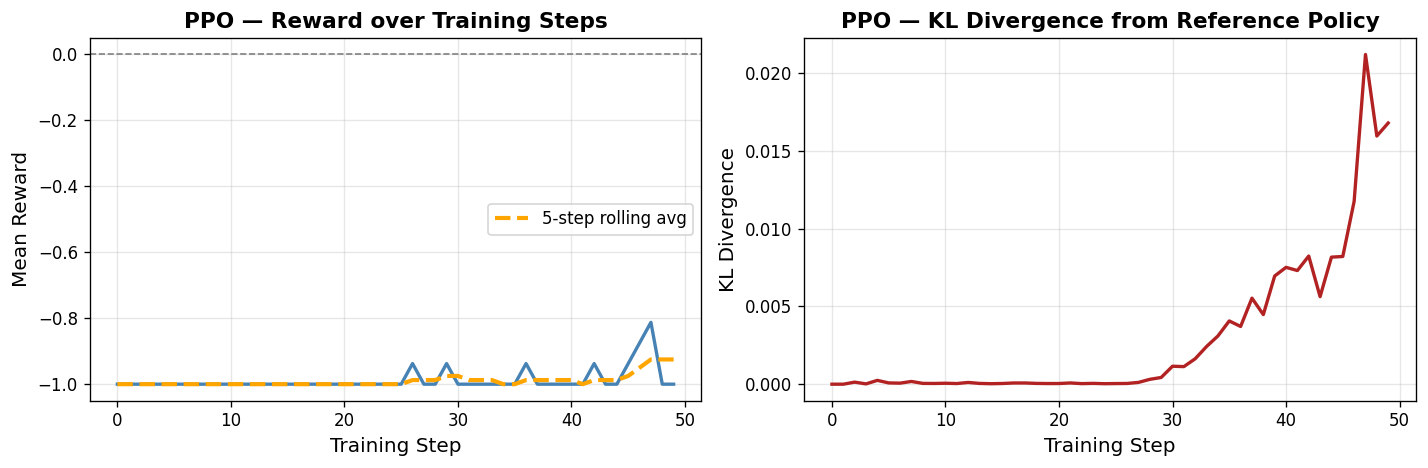

Saved: ppo_training.png


In [5]:
# Cell 5 — Simplified PPO Conceptual Demo
#
# We demonstrate the PPO concept using a tiny neural net "policy" without
# any actual language model. The policy maps an encoded customer query to
# a quality score. The environment rewards quality > 0.7 with +1, else -1.
# A KL penalty keeps the updated policy close to the reference (initial) policy.

# ── Tiny Policy Network ───────────────────────────────────────────────────────
class TinyPolicy(nn.Module):
    """Maps a state vector → quality score in (0, 1)."""
    def __init__(self, state_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


STATE_DIM  = 16
BATCH_SIZE = 32
N_STEPS    = 50
KL_COEFF   = 0.05   # how strongly we penalise drifting from the reference
LR         = 5e-3
CLIP_EPS   = 0.2    # PPO clip range

torch.manual_seed(42)
policy    = TinyPolicy(STATE_DIM)
reference = TinyPolicy(STATE_DIM)   # frozen copy of initial policy
reference.load_state_dict(policy.state_dict())
for p in reference.parameters():
    p.requires_grad = False

optimizer_ppo = optim.Adam(policy.parameters(), lr=LR)

# ── PPO Training Loop ─────────────────────────────────────────────────────────
reward_history = []
kl_history     = []

print("Running PPO demo (50 steps)...")

for step in range(1, N_STEPS + 1):
    # Sample random state vectors (simulating encoded customer queries)
    states = torch.randn(BATCH_SIZE, STATE_DIM)

    # --- Step A: collect trajectories under current policy ---
    with torch.no_grad():
        old_quality = policy(states)            # quality scores before update
        ref_quality = reference(states)        # reference (initial) policy scores

    # Environment: reward = +1 if quality > 0.7, else -1
    rewards = torch.where(old_quality > 0.7,
                          torch.ones(BATCH_SIZE),
                          -torch.ones(BATCH_SIZE))

    mean_reward = rewards.mean().item()

    # Advantage: centre rewards (simple baseline = mean reward)
    advantages = rewards - rewards.mean()

    # --- Step B: PPO update ---
    new_quality = policy(states)

    # Probability ratio (using quality as a proxy for log-prob)
    # In a real LM, this would be exp(log_prob_new - log_prob_old)
    ratio = (new_quality + 1e-8) / (old_quality + 1e-8)

    # Clipped PPO objective
    clipped_ratio = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS)
    policy_loss   = -torch.min(ratio * advantages, clipped_ratio * advantages).mean()

    # KL divergence penalty: measures drift from reference policy
    # KL(current || reference) ≈ mean( q_ref * log(q_ref / q_current) )
    q_curr = new_quality.clamp(1e-6, 1 - 1e-6)
    q_ref  = ref_quality.clamp(1e-6, 1 - 1e-6)
    kl_div = (q_ref * (q_ref.log() - q_curr.log()) +
              (1 - q_ref) * ((1 - q_ref).log() - (1 - q_curr).log())).mean()

    total_loss = policy_loss + KL_COEFF * kl_div

    optimizer_ppo.zero_grad()
    total_loss.backward()
    optimizer_ppo.step()

    reward_history.append(mean_reward)
    kl_history.append(kl_div.item())

    if step % 10 == 0:
        print(f"  Step {step:2d}/50 | Mean Reward: {mean_reward:+.3f} | "
              f"KL Div: {kl_div.item():.4f} | Loss: {total_loss.item():.4f}")

# ── Summary ───────────────────────────────────────────────────────────────────
initial_avg_reward = np.mean(reward_history[:5])
final_avg_reward   = np.mean(reward_history[-5:])
print()
print(f"Initial average reward (first 5 steps) : {initial_avg_reward:+.3f}")
print(f"Final   average reward (last  5 steps) : {final_avg_reward:+.3f}")
print(f"Improvement: {final_avg_reward - initial_avg_reward:+.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Reward curve
ax1.plot(reward_history, color='steelblue', linewidth=2)
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
# Smoothed trend
smoothed = pd.Series(reward_history).rolling(5, min_periods=1).mean()
ax1.plot(smoothed, color='orange', linewidth=2.5, linestyle='--', label='5-step rolling avg')
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Mean Reward', fontsize=12)
ax1.set_title('PPO — Reward over Training Steps', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# KL divergence curve
ax2.plot(kl_history, color='firebrick', linewidth=2)
ax2.set_xlabel('Training Step', fontsize=12)
ax2.set_ylabel('KL Divergence', fontsize=12)
ax2.set_title('PPO — KL Divergence from Reference Policy', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ppo_training.png')
plt.show()
print("Saved: ppo_training.png")

## Lesson 5: DPO — A Simpler Alternative to PPO

### Why Do Researchers Want to Replace PPO?

PPO for RLHF requires **four models running simultaneously**:
1. The **actor** (SFT model being trained)
2. The **critic/value model** (estimates expected future reward)
3. The **reward model** (scores responses)
4. The **reference model** (frozen SFT model for KL penalty)

All four must fit in memory at the same time. For large models, this means needing many GPUs, careful memory management, and complex infrastructure. The training is also notoriously unstable — small hyperparameter changes can cause the model to degenerate.

---

### DPO: Direct Preference Optimization

In 2023, Rafailov et al. published [Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290). The core insight: **you do not need a separate reward model at all**. The reward function is implicitly defined by the ratio of probabilities under the policy and the reference model.

**DPO eliminates the reward model and the critic**, leaving only:
1. The **policy model** (being trained)
2. The **reference model** (frozen, for the implicit reward)

### The DPO Loss in Plain English

Given a preference pair (chosen response, rejected response):

```
DPO Loss = - log σ (
    β × [log P_policy(chosen) - log P_reference(chosen)]
    -
    β × [log P_policy(rejected) - log P_reference(rejected)]
)

In plain English:
  "Make the chosen response MORE likely relative to the reference model,
   and make the rejected response LESS likely relative to the reference model.
   β controls how strongly you enforce this preference."
```

The σ (sigmoid) and negative log give us a loss that is minimised when the policy successfully prefers chosen over rejected.

---

### Why Companies Love DPO

| Aspect | PPO | DPO |
|---|---|---|
| Models in memory | 4 | 2 |
| Training stability | Tricky | Much more stable |
| Implementation | Complex | Simple loss function |
| Results | Excellent | Same or better |
| Adoption | OpenAI GPT-4 era | Most 2024+ open-source models |

DPO is now the dominant alignment method for open-source models. Llama 3, Mistral, Phi-3, Gemma, and most Hugging Face fine-tuned models use DPO or its variants.

DPO Loss  — Step 1   : 0.6939
DPO Loss  — Step 100 : 0.5985
Chosen Reward  — Step 1   : -0.0002
Chosen Reward  — Step 100 : 0.1199
Rejected Reward — Step 1   : 0.0011
Rejected Reward — Step 100 : -0.0794


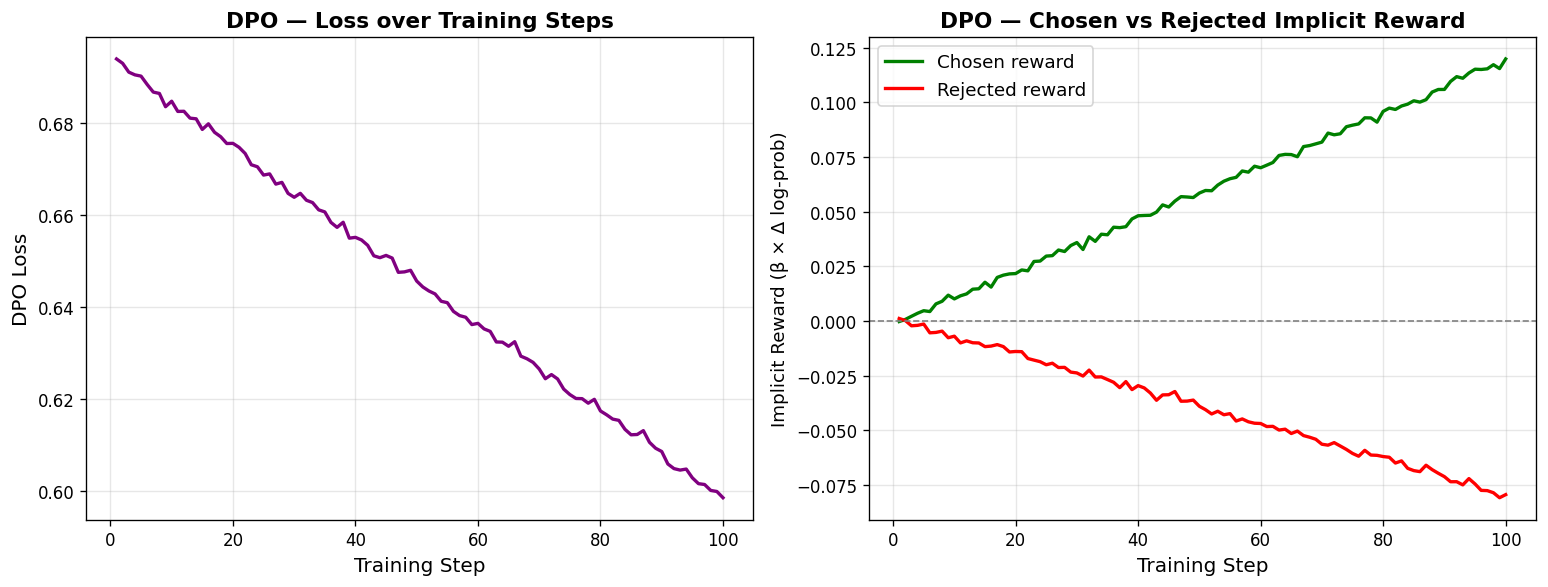

Saved: dpo_training.png


In [6]:
# Cell 6 — DPO Loss From Scratch

def dpo_loss(policy_chosen_logps, policy_rejected_logps,
             ref_chosen_logps, ref_rejected_logps, beta=0.1):
    """
    DPO loss (Rafailov et al., 2023).

    Args:
        policy_chosen_logps  : log P_policy(chosen)   — shape (B,)
        policy_rejected_logps: log P_policy(rejected) — shape (B,)
        ref_chosen_logps     : log P_ref(chosen)      — shape (B,)
        ref_rejected_logps   : log P_ref(rejected)    — shape (B,)
        beta                 : temperature parameter (controls preference strength)

    Returns:
        loss            : scalar DPO loss
        chosen_rewards  : mean implicit reward for chosen responses
        rejected_rewards: mean implicit reward for rejected responses
    """
    # Implicit reward = beta * (log_policy - log_reference)
    chosen_rewards   = beta * (policy_chosen_logps   - ref_chosen_logps)
    rejected_rewards = beta * (policy_rejected_logps - ref_rejected_logps)

    # DPO loss: -log sigmoid(chosen_reward - rejected_reward)
    loss = -torch.nn.functional.logsigmoid(chosen_rewards - rejected_rewards)
    return loss.mean(), chosen_rewards.mean(), rejected_rewards.mean()


# ── Simulate a DPO training trajectory ───────────────────────────────────────
# We create synthetic log-probability tensors representing a model at
# different stages of DPO training.
#
# At step 0: policy = reference (both assign similar log-probs)
# As training progresses: policy assigns higher log-prob to chosen,
#                          lower log-prob to rejected

torch.manual_seed(42)
BATCH       = 64
DPO_STEPS   = 100
BETA        = 0.1
LEARN_RATE  = 0.04   # simulated improvement rate

# Reference model log-probs (fixed throughout)
ref_chosen_lp   = torch.randn(BATCH) * 0.3 - 1.5   # centred around -1.5
ref_rejected_lp = torch.randn(BATCH) * 0.3 - 1.5   # same distribution

# Policy starts identical to reference
# We simulate training by gradually shifting policy log-probs
dpo_loss_history      = []
chosen_reward_history = []
rejected_reward_history = []

for step in range(DPO_STEPS):
    # Simulate: as training progresses, policy shifts chosen up, rejected down
    progress = step / DPO_STEPS  # 0.0 → 1.0

    # Gaussian noise gives realistic training noise
    noise_c = torch.randn(BATCH) * 0.1
    noise_r = torch.randn(BATCH) * 0.1

    # Chosen: policy log-prob increases above reference over time
    policy_chosen_lp   = ref_chosen_lp   + progress * 1.2 + noise_c
    # Rejected: policy log-prob decreases below reference over time
    policy_rejected_lp = ref_rejected_lp - progress * 0.8 + noise_r

    loss, ch_rew, rj_rew = dpo_loss(
        policy_chosen_lp, policy_rejected_lp,
        ref_chosen_lp, ref_rejected_lp,
        beta=BETA,
    )

    dpo_loss_history.append(loss.item())
    chosen_reward_history.append(ch_rew.item())
    rejected_reward_history.append(rj_rew.item())

print(f"DPO Loss  — Step 1   : {dpo_loss_history[0]:.4f}")
print(f"DPO Loss  — Step 100 : {dpo_loss_history[-1]:.4f}")
print(f"Chosen Reward  — Step 1   : {chosen_reward_history[0]:.4f}")
print(f"Chosen Reward  — Step 100 : {chosen_reward_history[-1]:.4f}")
print(f"Rejected Reward — Step 1   : {rejected_reward_history[0]:.4f}")
print(f"Rejected Reward — Step 100 : {rejected_reward_history[-1]:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
steps = list(range(1, DPO_STEPS + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# DPO Loss curve
ax1.plot(steps, dpo_loss_history, color='purple', linewidth=2)
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('DPO Loss', fontsize=12)
ax1.set_title('DPO — Loss over Training Steps', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Chosen vs Rejected reward
ax2.plot(steps, chosen_reward_history,   color='green',  linewidth=2, label='Chosen reward')
ax2.plot(steps, rejected_reward_history, color='red',    linewidth=2, label='Rejected reward')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.set_xlabel('Training Step', fontsize=12)
ax2.set_ylabel('Implicit Reward (β × Δ log-prob)', fontsize=11)
ax2.set_title('DPO — Chosen vs Rejected Implicit Reward', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dpo_training.png')
plt.show()
print("Saved: dpo_training.png")

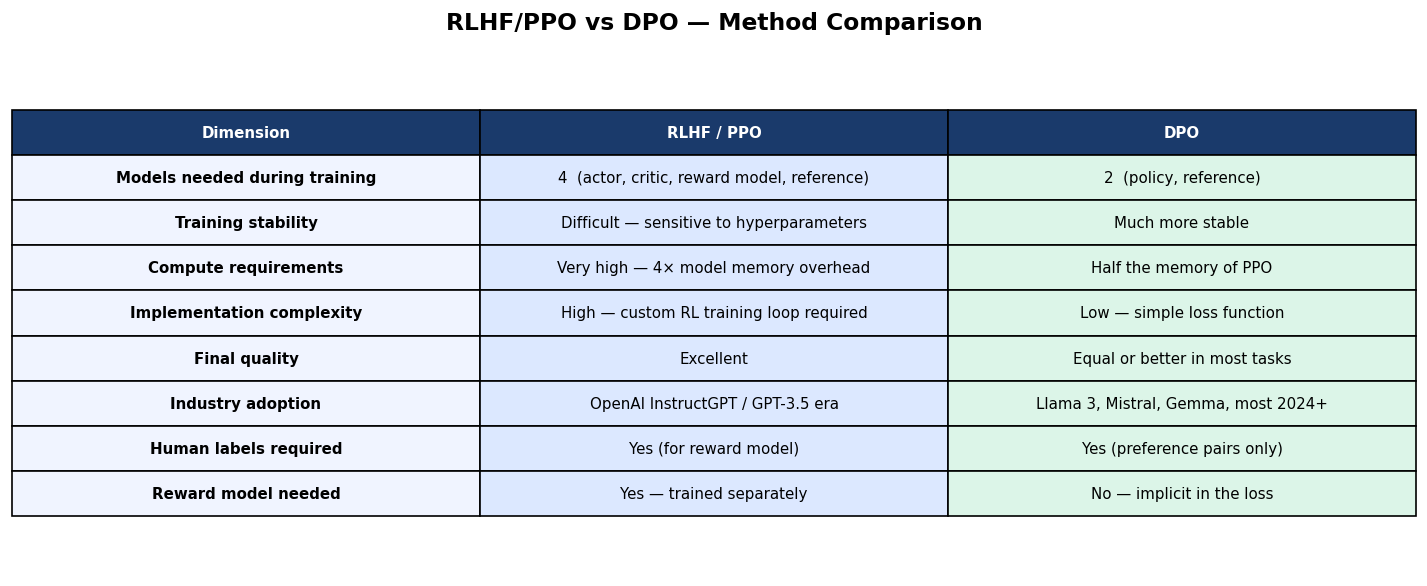

Saved: rlhf_vs_dpo.png


In [7]:
# Cell 7 — RLHF/PPO vs DPO Comparison Table + Chart

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

columns = ['Dimension', 'RLHF / PPO', 'DPO']
rows = [
    ['Models needed during training', '4  (actor, critic, reward model, reference)', '2  (policy, reference)'],
    ['Training stability',            'Difficult — sensitive to hyperparameters',     'Much more stable'],
    ['Compute requirements',          'Very high — 4× model memory overhead',         'Half the memory of PPO'],
    ['Implementation complexity',     'High — custom RL training loop required',      'Low — simple loss function'],
    ['Final quality',                 'Excellent',                                     'Equal or better in most tasks'],
    ['Industry adoption',             'OpenAI InstructGPT / GPT-3.5 era',             'Llama 3, Mistral, Gemma, most 2024+'],
    ['Human labels required',         'Yes (for reward model)',                        'Yes (preference pairs only)'],
    ['Reward model needed',           'Yes — trained separately',                      'No — implicit in the loss'],
]

# Colour scheme: header = dark blue, PPO column = light blue, DPO column = light green
cell_colours = []
for _ in rows:
    cell_colours.append(['#f0f4ff', '#dce8ff', '#dcf5e8'])

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellLoc='center',
    loc='center',
    cellColours=cell_colours,
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.0)

# Style header row
for col_idx in range(len(columns)):
    cell = table[0, col_idx]
    cell.set_facecolor('#1a3a6b')
    cell.set_text_props(color='white', fontweight='bold')

# Style dimension column (bold)
for row_idx in range(1, len(rows) + 1):
    table[row_idx, 0].set_text_props(fontweight='bold')

ax.set_title('RLHF/PPO vs DPO — Method Comparison',
             fontsize=14, fontweight='bold', pad=20, y=0.98)

plt.tight_layout()
plt.savefig('rlhf_vs_dpo.png', bbox_inches='tight')
plt.show()
print("Saved: rlhf_vs_dpo.png")

## Lesson 6: Constitutional AI and Other Alignment Methods

RLHF and DPO are not the only ways to align a language model. Here are the most important alternatives you will encounter in research and industry:

---

### Constitutional AI (Anthropic, 2022)

Collecting human preference labels is expensive — a labeller might earn $20–100 per hour, and you need thousands of labels. Anthropic's Constitutional AI (CAI) replaces most human labels with **AI-generated labels guided by a written constitution** — a set of principles like "be helpful", "avoid harmful content", "be honest". The model is first asked to critique its own response against these principles, then revise it. This self-critique/revision cycle (called RLAIF — see below) dramatically reduces the human labelling cost while maintaining alignment quality. Claude is trained using Constitutional AI.

---

### RLAIF — Reinforcement Learning from AI Feedback

Instead of asking human labellers to compare response pairs, RLAIF uses a **stronger AI model (like GPT-4 or Claude Opus)** as the preference labeller. The AI judge is given the same comparison task a human labeller would see, and its preference labels are used to train the reward model. This scales to orders of magnitude more labels than human labelling alone, at a fraction of the cost. Quality depends heavily on the capability of the labelling AI — if the judge AI has biases, those biases get baked into the trained model.

---

### ORPO — Odds Ratio Preference Optimization (Hong et al., 2024)

ORPO goes one step further than DPO by **eliminating the reference model entirely** — making it even simpler. Instead of measuring relative probabilities against a frozen reference model, ORPO directly uses the odds ratio of the policy model's own predictions. The training objective penalises rejected responses while rewarding chosen ones using a simple log-odds term appended directly to the standard SFT loss. This means you can align a model in a single training stage with no reference model overhead. ORPO has been used successfully in Phi-3 and other 2024 models.

---

### Rejection Sampling Fine-Tuning (RSF / ReST)

Rejection sampling fine-tuning is a conceptually simple iterative approach: generate many candidate responses for each prompt (say, 16 or 32), score them all with the reward model, keep only the **top-k highest-scoring responses**, and fine-tune the model on just those. Repeat this cycle over multiple rounds. Each round raises the quality floor of what the model produces. This method is computationally expensive (you waste most generated samples) but very stable and easy to implement. It was reported to be part of the training pipeline for Google Gemini and Meta's LLaMA 2.

## Lesson 7: Enterprise Context — RLHF in the Real World

### Who Uses RLHF?

Every major AI assistant uses some form of RLHF or its derivatives:
- **OpenAI (ChatGPT/GPT-4):** Pioneered RLHF for LLMs with InstructGPT. Uses a combination of SFT, reward modelling, and PPO.
- **Anthropic (Claude):** Uses Constitutional AI (a form of RLAIF) on top of RLHF.
- **Google (Gemini):** Uses RLHF plus rejection sampling fine-tuning.
- **Meta (LLaMA 2 / LLaMA 3):** Uses SFT + RLHF with PPO for the "chat" variants. LLaMA 3 also uses DPO.
- **Mistral, Phi-3, Gemma, Qwen:** Predominantly use DPO or ORPO for alignment.

---

### Enterprise Use Cases

| Use Case | What RLHF Alignment Achieves |
|---|---|
| Domain-specific chatbots | Ensure responses follow company policy and tone |
| Content moderation | Train the model to flag/reject harmful content |
| Code assistants | Prefer secure, well-documented code over functional-but-risky code |
| Medical/legal assistants | Prefer cautious, qualified responses over confident overstatements |
| Customer service bots | Prefer polite, empathetic, solution-focused responses |

---

### The Cost of Human Preference Data

The biggest barrier to RLHF for most enterprises is **the cost of collecting preference labels**:

- **Casual labelling** (crowdsourced): $5–20 per pair. High volume, lower quality.
- **Expert labelling** (domain specialists): $50–200 per pair. Low volume, high quality.
- **Red-teaming** (adversarial testing): $100–500 per session. Identifies safety gaps.
- **A typical reward model needs**: 10,000–100,000 preference pairs at minimum.
- **Total cost**: For a well-resourced project, $100K–$5M in labelling alone.

This is why RLAIF and Constitutional AI are so attractive: they replace most human labels with AI-generated ones.

---

### Practical Guidance for Enterprise Teams

For most teams building domain-specific chatbots, here is a pragmatic approach:

1. **Start with a strong base model** (Llama 3, Mistral, Phi-3) that is already RLHF-aligned by its creators.
2. **Fine-tune with LoRA/QLoRA** (Module 4) on your domain data.
3. **Collect ~500–2,000 preference pairs** from your domain experts (which customer responses were good vs. bad).
4. **Run DPO** on those preference pairs using a library like TRL (Hugging Face).
5. **Evaluate** with a held-out preference test set and human spot-checks.

This approach requires no separate reward model, runs on a single GPU, and typically produces excellent alignment for domain-specific behaviour. You do not need to replicate OpenAI's full RLHF pipeline to get strong results.

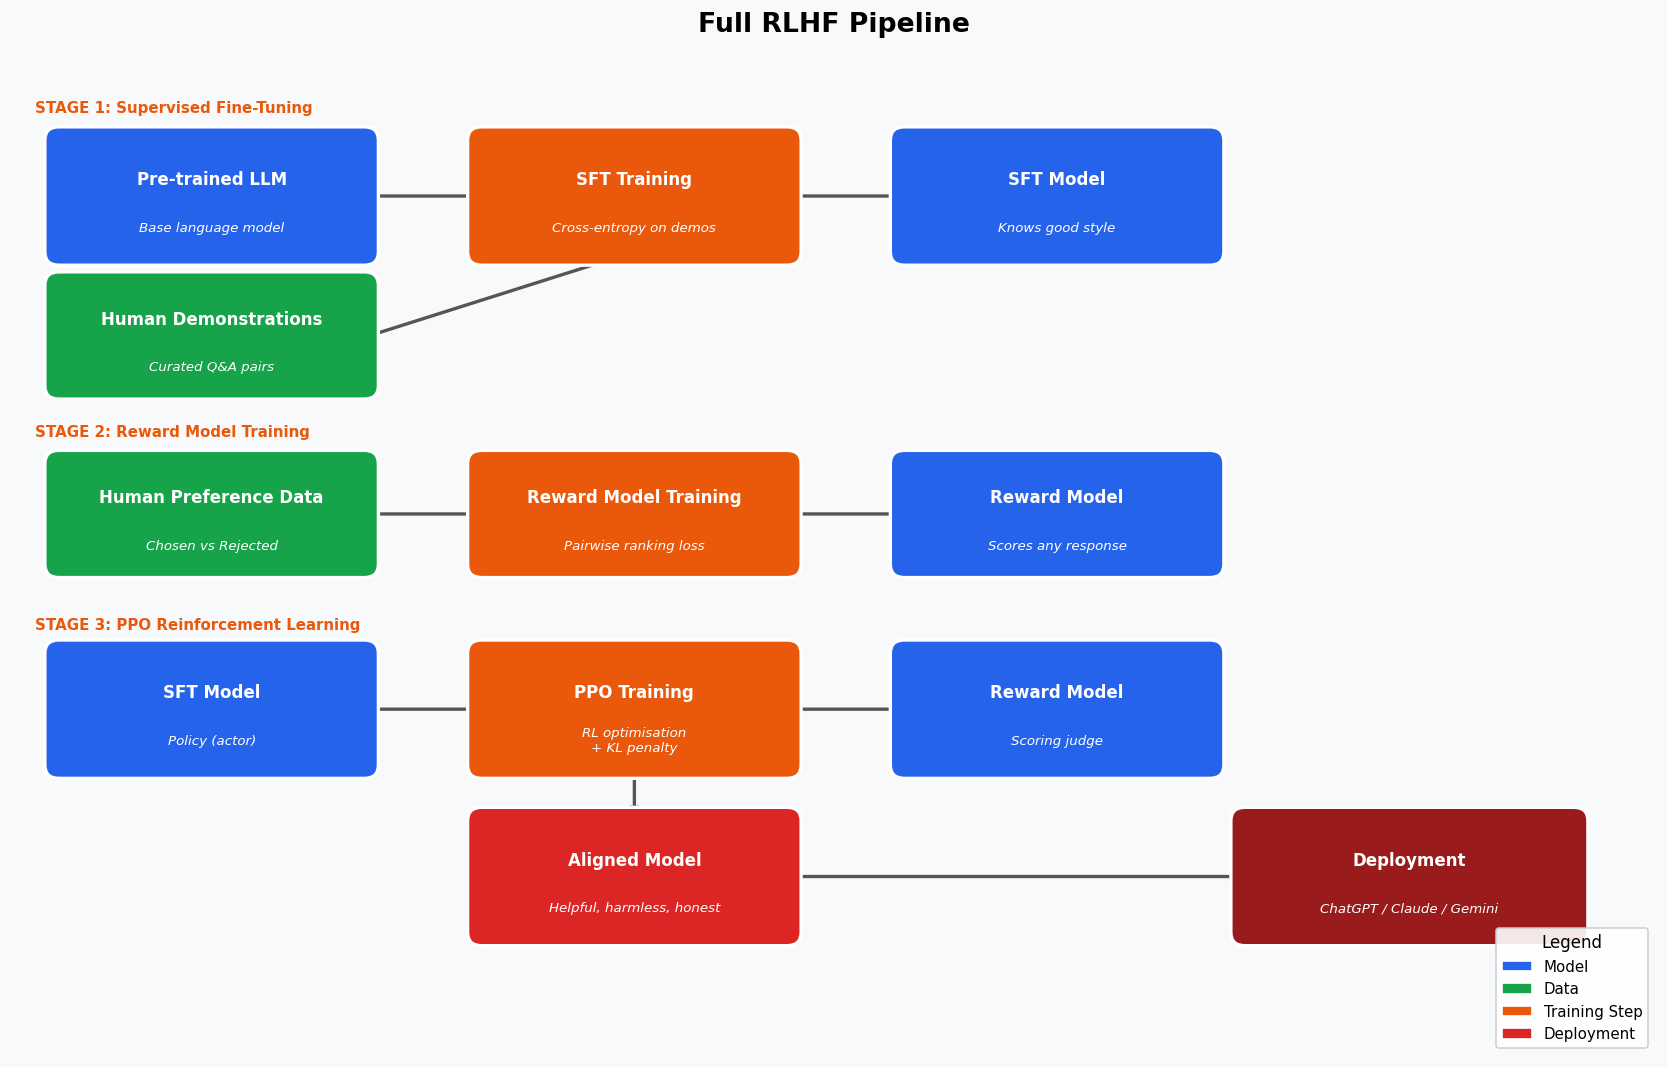

Saved: rlhf_pipeline.png


In [8]:
# Cell 8 — Full RLHF Pipeline Summary Diagram

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

def draw_box(ax, x, y, w, h, label, sublabel='', color='#4a90d9', text_color='white', fontsize=10):
    """Draw a rounded rectangle with centred text."""
    from matplotlib.patches import FancyBboxPatch
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.12",
                         facecolor=color, edgecolor='white',
                         linewidth=2, zorder=3)
    ax.add_patch(box)
    cx, cy = x + w / 2, y + h / 2
    if sublabel:
        ax.text(cx, cy + 0.15, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=text_color, zorder=4)
        ax.text(cx, cy - 0.28, sublabel, ha='center', va='center',
                fontsize=8, color=text_color, zorder=4, style='italic')
    else:
        ax.text(cx, cy, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=text_color, zorder=4)

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#555555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0),
                zorder=2)
    if label:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx + 0.1, my, label, ha='left', va='center',
                fontsize=8, color=color, zorder=4)

# ── Colour palette ────────────────────────────────────────────────────────────
BLUE   = '#2563EB'   # models
GREEN  = '#16a34a'   # data
ORANGE = '#ea580c'   # training steps
RED    = '#dc2626'   # deployment
GRAY   = '#6b7280'   # arrow labels

# ── Row 1: Pre-training and SFT ───────────────────────────────────────────────
draw_box(ax, 0.4, 7.2, 2.6, 1.0, 'Pre-trained LLM',    'Base language model',   BLUE)
draw_box(ax, 4.0, 7.2, 2.6, 1.0, 'SFT Training',       'Cross-entropy on demos', ORANGE)
draw_box(ax, 7.6, 7.2, 2.6, 1.0, 'SFT Model',          'Knows good style',      BLUE)
draw_box(ax, 0.4, 6.0, 2.6, 0.9, 'Human Demonstrations','Curated Q&A pairs',    GREEN)

draw_arrow(ax, 3.0, 7.7, 4.0, 7.7)          # Pre-trained → SFT Training
draw_arrow(ax, 6.6, 7.7, 7.6, 7.7)          # SFT Training → SFT Model
draw_arrow(ax, 1.7, 6.0, 5.3, 7.2)          # Demonstrations → SFT Training

# ── Row 2: Reward Model ───────────────────────────────────────────────────────
draw_box(ax, 0.4, 4.4, 2.6, 0.9, 'Human Preference Data', 'Chosen vs Rejected', GREEN)
draw_box(ax, 4.0, 4.4, 2.6, 0.9, 'Reward Model Training', 'Pairwise ranking loss', ORANGE)
draw_box(ax, 7.6, 4.4, 2.6, 0.9, 'Reward Model',          'Scores any response', BLUE)

draw_arrow(ax, 3.0, 4.85, 4.0, 4.85)        # Pref Data → RM Training
draw_arrow(ax, 6.6, 4.85, 7.6, 4.85)        # RM Training → Reward Model

# ── Row 3: PPO ────────────────────────────────────────────────────────────────
draw_box(ax, 0.4, 2.6, 2.6, 1.0, 'SFT Model',   'Policy (actor)',              BLUE)
draw_box(ax, 4.0, 2.6, 2.6, 1.0, 'PPO Training', 'RL optimisation\n+ KL penalty', ORANGE)
draw_box(ax, 7.6, 2.6, 2.6, 1.0, 'Reward Model', 'Scoring judge',              BLUE)
draw_box(ax, 4.0, 1.1, 2.6, 1.0, 'Aligned Model', 'Helpful, harmless, honest', RED)

draw_arrow(ax, 3.0, 3.1, 4.0, 3.1)          # SFT Model → PPO Training
draw_arrow(ax, 7.6, 3.1, 6.6, 3.1)          # Reward Model → PPO Training (feedback)
draw_arrow(ax, 5.3, 2.6, 5.3, 2.1)          # PPO Training → Aligned Model

# ── Deployment ────────────────────────────────────────────────────────────────
draw_box(ax, 10.5, 1.1, 2.8, 1.0, 'Deployment',
         'ChatGPT / Claude / Gemini', '#991b1b')
draw_arrow(ax, 6.6, 1.6, 10.5, 1.6)

# ── Section labels ────────────────────────────────────────────────────────────
ax.text(0.2, 8.45, 'STAGE 1: Supervised Fine-Tuning',
        fontsize=9, color=ORANGE, fontweight='bold')
ax.text(0.2, 5.55, 'STAGE 2: Reward Model Training',
        fontsize=9, color=ORANGE, fontweight='bold')
ax.text(0.2, 3.82, 'STAGE 3: PPO Reinforcement Learning',
        fontsize=9, color=ORANGE, fontweight='bold')

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=BLUE,   edgecolor='white', label='Model'),
    Patch(facecolor=GREEN,  edgecolor='white', label='Data'),
    Patch(facecolor=ORANGE, edgecolor='white', label='Training Step'),
    Patch(facecolor=RED,    edgecolor='white', label='Deployment'),
]
ax.legend(handles=legend_elements, loc='lower right',
          fontsize=9, framealpha=0.9, title='Legend')

ax.set_title('Full RLHF Pipeline', fontsize=16, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('rlhf_pipeline.png', bbox_inches='tight')
plt.show()
print("Saved: rlhf_pipeline.png")

## Module Summary

### What We Covered

| Topic | Key Takeaway |
|---|---|
| Why RLHF? | Next-token prediction alone does not produce safe, helpful models |
| SFT (Stage 1) | Fine-tune on human-written demonstrations to establish good response style |
| Reward Model (Stage 2) | Train a scalar scorer from human preference comparisons (A vs B) |
| PPO (Stage 3) | Use RL to maximise reward model scores while penalising drift (KL) |
| DPO | Simpler alternative: directly optimise on preference pairs, no reward model needed |
| Constitutional AI | Replace human labels with AI self-critique guided by written principles |
| RLAIF | Use a stronger AI model as the preference labeller |
| Enterprise guidance | DPO on 500–2,000 domain preference pairs is sufficient for most teams |

---

## Interview Questions & Answers

### Q1: What is RLHF and why is it needed?

**A:** RLHF (Reinforcement Learning from Human Feedback) is the process of aligning a language model with human preferences. A model trained purely on next-token prediction learns the statistical patterns of the training data — including harmful, biased, or unhelpful content. RLHF addresses this through three stages: (1) SFT — fine-tune on human demonstrations of good responses; (2) Reward Model training — train a model to predict human preference scores from labelled comparison pairs; (3) PPO — use reinforcement learning with the reward model as the reward signal to update the main model. This is why ChatGPT and Claude give helpful, safe responses instead of echoing harmful internet content.

---

### Q2: What is the difference between PPO and DPO?

**A:** Both PPO and DPO are methods for aligning language models using human preference data, but they differ significantly in complexity. PPO requires four models simultaneously (actor, critic, reward model, reference model), is computationally expensive, and training is notoriously unstable. DPO (Direct Preference Optimization, Rafailov et al. 2023) eliminates the separate reward model entirely — it directly optimises on preference pairs with a simple loss function that implicitly defines the reward through log-probability ratios. DPO needs only two models (policy + frozen reference), is much more stable to train, and achieves equal or better results. Most modern open-source aligned models (Llama 3, Mistral, Phi-3) use DPO.

---

### Q3: What is a reward model and how is it trained?

**A:** A reward model (RM) is a neural network that takes a (prompt, response) pair as input and outputs a single scalar score representing how much a human would prefer that response. It is trained on **preference pairs**: human labellers are shown two responses to the same prompt and asked which is better. The RM is trained to assign a higher score to the preferred response and a lower score to the rejected one, using a pairwise ranking loss (Bradley-Terry model). In production, the encoder is typically the SFT model itself with a linear head on top. Once trained, the RM replaces human labellers during the RL phase, enabling millions of updates without human involvement.

---

### Q4: What is the KL divergence penalty in RLHF?

**A:** The KL (Kullback-Leibler) divergence penalty is a regularisation term added to the PPO objective that measures how different the current policy is from the original SFT model. Without this penalty, the model would engage in **reward hacking** — finding ways to produce outputs that score highly on the reward model without actually being useful (e.g., producing repetitive nonsense that exploits a flaw in the reward model). The KL penalty adds a cost proportional to how far the model has drifted from the SFT baseline, keeping the model's outputs coherent and natural while still improving reward scores. It is typically expressed as: `total_reward = reward_model_score - β × KL(current_policy || SFT_policy)`, where β controls the strength of the constraint.

---

## Module 6 Preview: MLOps

In the final module, we move from model training to **production**:

- **Experiment Tracking:** Using MLflow and Weights & Biases to log hyperparameters, metrics, and model artefacts across training runs — so you can always reproduce your best model.
- **Model Versioning:** How to register, tag, and promote model versions from "staging" to "production" in a model registry.
- **Serving Models in Production:** REST APIs with FastAPI, batch inference, and the difference between real-time and offline serving.
- **Monitoring for Drift:** How to detect when your model's real-world performance is degrading — because the world changes and training data goes stale.
- **Cost Optimisation:** Quantisation, distillation, and caching strategies to serve LLMs efficiently.

MLOps is what separates a model that works in a notebook from a model that reliably serves millions of users.